In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
c1 = fits.open('/dat/milic/MURaM_SSD_che/ssd_che_0_512x_399000_lwsynth_392.8.fits')
c1.info()

Filename: /dat/milic/MURaM_SSD_che/ssd_che_0_512x_399000_lwsynth_392.8.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (1001, 1, 1024, 512)   float64   
  1                1 ImageHDU         6   (1001,)   float64   
  2                1 ImageHDU         9   (401, 6, 1024, 512)   float64   


In [3]:
c2 = fits.open('/dat/milic/MURaM_SSD_che/ssd_che_512_768x_399000_lwsynth_392.8.fits')
c2.info()

Filename: /dat/milic/MURaM_SSD_che/ssd_che_512_768x_399000_lwsynth_392.8.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (1001, 1, 1024, 256)   float64   
  1                1 ImageHDU         6   (1001,)   float64   
  2                1 ImageHDU         9   (401, 6, 1024, 256)   float64   


In [4]:
c3 = fits.open('/dat/milic/MURaM_SSD_che/ssd_che_768_1024x_399000_lwsynth_392.8.fits')
c3.info()

Filename: /dat/milic/MURaM_SSD_che/ssd_che_768_1024x_399000_lwsynth_392.8.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (1001, 1, 1024, 256)   float64   
  1                1 ImageHDU         6   (1001,)   float64   
  2                1 ImageHDU         9   (401, 6, 1024, 256)   float64   


In [5]:
s = np.concatenate((c1[0].data, c2[0].data, c3[0].data), axis=0)

In [6]:
ll = c1[1].data

In [7]:
p = np.concatenate((c1[2].data, c2[2].data, c3[2].data), axis=0)

In [8]:
s.shape

(1024, 1024, 1, 1001)

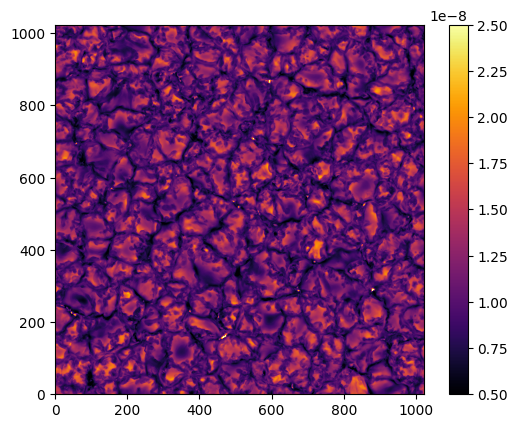

In [13]:
plt.imshow(s[:,:,0,0].T, origin='lower', cmap='inferno',vmin=5E-9, vmax=2.5E-8)
plt.colorbar()

In [10]:
# Repack into a fits: 
shdu = fits.PrimaryHDU(s)
llhdu = fits.ImageHDU(ll)
phdu = fits.ImageHDU(p)
hdulist = fits.HDUList([shdu, llhdu, phdu])
hdulist.writeto('/dat/milic/MURaM_SSD_che/ssd_che_full_399000_lwsynth_392.8.fits', overwrite=True)